In [79]:
# ============================================================================
# IMPORTS AND SETUP
# ============================================================================
# Data manipulation and visualization libraries
import pandas as pd            
import numpy as np             
import utils                     
import seaborn as sns            
from matplotlib import rcParams 
import matplotlib.pyplot as plt   
from tqdm import tqdm            
from scipy import stats         
from importlib import reload   

# Configure figure styling for publication quality
utils.set_figure_style(scale="1col")  # Set figure dimensions and fonts
sns.set_palette("colorblind")         # Use colorblind-friendly palette

# Wiestler Transfer Experiment (one sequence training unpublished)

In [80]:
# ============================================================================
# DATA LOADING - Wiestler Single Sequence Transfer Experiment
# ============================================================================
# Experimental parameters
n_trials_per_block = 20           # Trials per block
n_blocks_per_day = 20             # Blocks per day
n_trials_per_day = n_trials_per_block * n_blocks_per_day
n_days = 3                        # Training spans 3 days

# Load force data: contains trial-by-trial force patterns during sequence execution
forces = pd.read_csv('./Data/Wiestler_Single_Seq_Forces.csv')
forces['ET'] = forces['ET'].astype('int')

# Create force_vector column: concatenate individual force measurements into arrays
# This enables vectorized distance calculations between trials
forces['force_vector'] = forces[[col for col in forces.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)

# Load subject-level data: contains behavioral metrics (execution time, errors, groups, etc.)
subjs = pd.read_csv('./Data/Wiestler_Single_Seq_Subjs.csv')

## Long-Term Dynamics

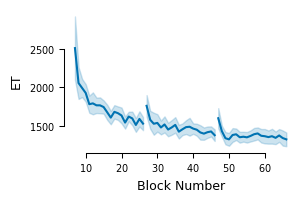

In [81]:
# ============================================================================
# EXECUTION TIME IMPROVEMENT ACROSS LEARNING
# ============================================================================
# Plot median execution time (ET) per subject and block
# Error trials (trialPoints == -1) are excluded

subjs_correct = subjs[subjs['trialPoints'] != -1]  # Remove error trials
grouped_subjs = subjs_correct.groupby(['SubNum', 'BN', 'day']).agg({'ET': 'median'}).reset_index()

# Plot ET across blocks, separated by day
for day, day_data in grouped_subjs.groupby('day'):
    sns.lineplot(data=day_data, x='BN', y='ET', errorbar='se', 
                 color=sns.color_palette("colorblind")[0])

plt.xlabel('Block Number')
sns.despine(trim=True)

In [82]:
# ============================================================================
# FORCE PATTERN DISTANCE CALCULATION
# ============================================================================
# Calculate pairwise distances between all force patterns

forces_correct = forces[forces['trialPoints'] != -1]  # Exclude error trials

# Calculate all pairwise force distances using utility function
distances_df = utils.calculate_force_distances(forces_correct)

100%|██████████| 16/16 [01:14<00:00,  4.68s/it]


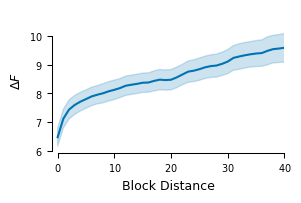

In [83]:
grouped_distances = distances_df.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se')

plt.xlabel('Block Distance')
plt.ylabel(r'$\Delta F$')

plt.xlim(-1, 40)
sns.despine(trim=True)


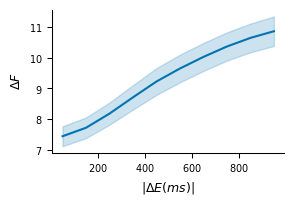

In [84]:
ET_diff_bin_size = 100
distances_df_filtered = distances_df.copy()
distances_df_filtered['ET_Distance'] = np.abs(distances_df_filtered['ET_Distance'])
distances_df_filtered['count'] = 1
distances_df_filtered = distances_df_filtered[(distances_df_filtered['ET_Distance'] < 1000) & (distances_df_filtered['ET_Distance'] > -1000)]
distances_df_filtered['ET_diff_bin'] = (distances_df_filtered['ET_Distance'] // ET_diff_bin_size) * ET_diff_bin_size + ET_diff_bin_size // 2
grouped_distances = distances_df_filtered.groupby(['SubNum', 'ET_diff_bin']).agg({'Force_Distance': 'median',
                                                                                'count': 'sum'}).reset_index()

hue_order = [True, False]  # True for ΔE >= 0, False for ΔE < 0
sns.lineplot(data = grouped_distances, x = 'ET_diff_bin', y = 'Force_Distance', errorbar = 'se', hue_order=hue_order)

# plt.title('Force Distance vs ET Distance')
plt.xlabel(r'$|\Delta E (ms)|$')
plt.ylabel(r'$\Delta F$')

sns.despine()


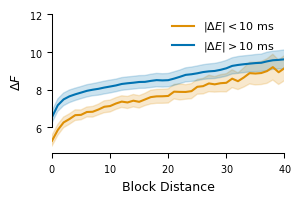

In [85]:
et_diff_cutoff = 10
matched_trials = distances_df[(distances_df['ET_Distance'] < et_diff_cutoff)
                              & (distances_df['ET_Distance'] > -et_diff_cutoff)].copy()
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()


sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = r'$|\Delta E| < $' + str(et_diff_cutoff) + ' ms',
             color = sns.color_palette("colorblind")[1])

et_diff_cutoff = 10
matched_trials = distances_df[(distances_df['ET_Distance'] > et_diff_cutoff)
                              | (distances_df['ET_Distance'] < -et_diff_cutoff)].copy()
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()


sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = r'$|\Delta E| > $' + str(et_diff_cutoff) + ' ms',
             color = sns.color_palette("colorblind")[0])


plt.xlabel('Block Distance')
plt.ylabel(r'$\Delta F$')

plt.xlim(0, 40)

plt.legend(frameon=False)
sns.despine(trim=True)




## Trial-by-trial Dynamics

100%|██████████| 16/16 [00:41<00:00,  2.58s/it]


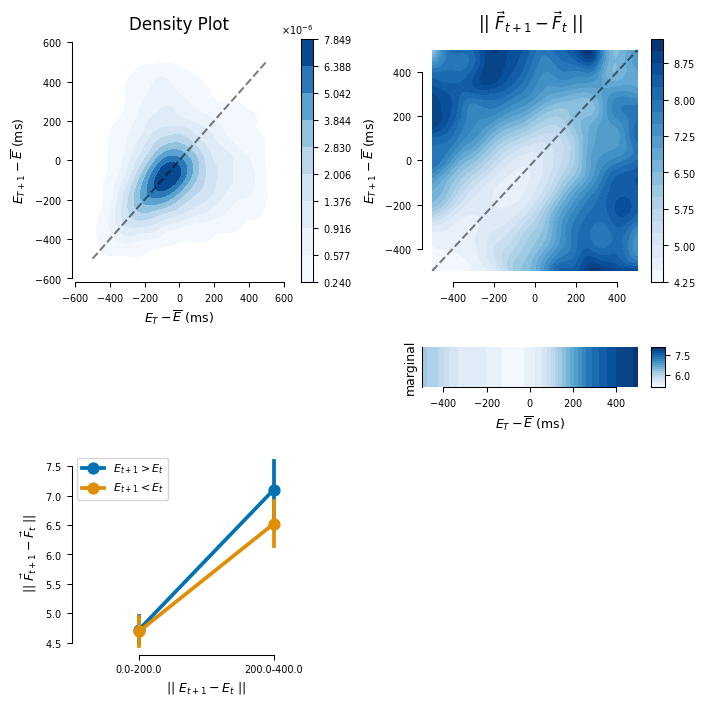

ANOVA results for neighbour distances:
                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
ET_diff_bin             54.4855 1.0000 15.0000 0.0000
is_pos_diff              4.4011 1.0000 15.0000 0.0533
ET_diff_bin:is_pos_diff  3.7227 1.0000 15.0000 0.0728



In [86]:
# Calculating the uclidean force distance between neighbouring trials.
# Controls for execution time differences.

distances = utils.calc_neighbour_distances(forces)
utils.plot_neighbour_distances(distances)

100%|██████████| 16/16 [00:16<00:00,  1.04s/it]

ANOVA results for for triplet distances::
                          Anova
                            F Value Num DF  Den DF Pr > F
---------------------------------------------------------
ET_diff_bin                 20.0024 1.0000 15.0000 0.0004
is_middle_error              6.6921 1.0000 15.0000 0.0206
ET_diff_bin:is_middle_error  0.0120 1.0000 15.0000 0.9142



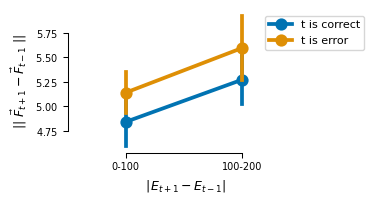

In [11]:
# Calculating the uclidean force distance between first and last trials of each triplet.
# Depending on whether the middle trial is error or correct.
# Controls for execution time differences.

distances = utils.calc_triplet_distances(forces)
utils.plot_triplet_distances(distances)

# Speed Clamping Experiment (one common sequence training) (Poster)

In [74]:
### Data Loading

num_sessions = 2
num_blocks_per_session = 15
num_baseline_blocks = 1
num_trials_per_block = 20
induction_blocks = list(range(5, 13))


subjs = pd.read_csv('./Data/Speed_Clamped_Subjs.csv')

forces = pd.read_csv('./Data/Speed_Clamped_Forces.csv')
forces['force_vector'] = forces[[col for col in forces.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)

# All force analysis done only on day 1, excluding error trials (Participants didn't particularly improve in day2)
forces_correct = utils.remove_error_trials(forces)
day1_forces = forces_correct[forces_correct['day'] == 1]


group_palette = {
    'Unclamped': sns.color_palette('colorblind')[0],
    'Clamped': sns.color_palette('colorblind')[1],
    'Verbal': 'gray'
}

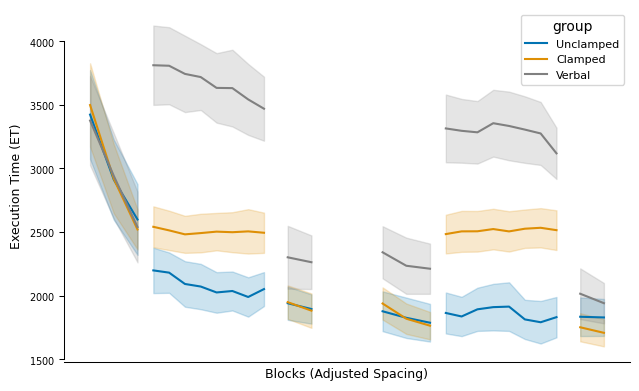

In [75]:
utils.plot_speed_clamped_ETs(subjs)

## Speed Independent Changes (During Clamp)

100%|██████████| 11/11 [00:00<00:00, 1916.64it/s]


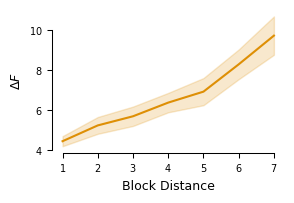

In [19]:
# Changes in force patterns during the clamping period

clamped_day1_forces = day1_forces[day1_forces['group'] == 'Clamped']
clamped_day1_forces = clamped_day1_forces[clamped_day1_forces['BN'].isin(induction_blocks)]
forces_grouped = clamped_day1_forces.groupby(['SubNum', 'BN']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0),
    'ET': 'median'
}).reset_index()

distances_df = utils.calculate_force_distances(forces_grouped)

grouped_distances = distances_df.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', color = sns.color_palette('colorblind')[1])

plt.xlabel('Block Distance')
plt.ylabel(r'$\Delta F$')
sns.despine(trim=True)


LOSO Cosine Similarities: 0.3254618383612928


TtestResult(statistic=4.267216433603348, pvalue=0.0016442018904605953, df=10)

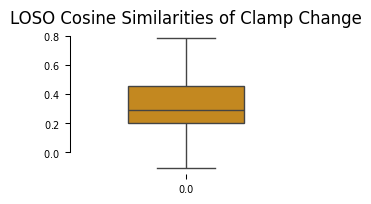

In [20]:
### correlation of the direction of force changes in clamped condition between participants

clamped_day1_forces = day1_forces[day1_forces['group'] == 'Clamped']
clamp_start_blocks = [4,5, 6]
clamp_end_blocks = [10, 11, 12]
post_clamp_blocks = [13, 14]

clamp_start_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(clamp_start_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0),
})['force_vector'].to_list())

clamp_end_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(clamp_end_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

start_to_end_vectors = clamp_end_forces - clamp_start_forces

# calculate leave one out cosine similarity of start_to_end_vectors across participants
similarities = []
for i in range(len(start_to_end_vectors)):
    left_out_vector = start_to_end_vectors[i]
    other_vectors = np.delete(start_to_end_vectors, i, axis=0)
    mean_other_vector = np.mean(other_vectors, axis=0)
    cosine_sim = np.dot(left_out_vector, mean_other_vector) / (np.linalg.norm(left_out_vector) * np.linalg.norm(mean_other_vector))
    # print(f"Subject {i}: Cosine Similarity = {cosine_sim:.4f}")
    similarities.append(cosine_sim)

sns.boxplot(x=np.zeros(len(similarities)), y=similarities, color = sns.color_palette('colorblind')[1], width = 0.5)
plt.title('LOSO Cosine Similarities of Clamp Change')
sns.despine(trim=True)

print("LOSO Cosine Similarities:", np.mean(similarities))
stats.ttest_1samp(similarities, 0)

TtestResult(statistic=3.6992420927891665, pvalue=0.0041136359733186705, df=10)


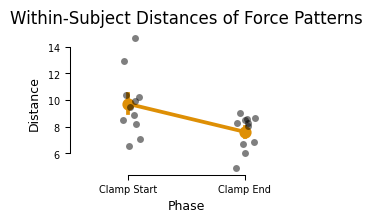

In [157]:
distances_start = []
distances_end = []
for subnum, subdata in clamped_day1_forces.groupby('SubNum'):
    clamp_forces_start = np.array(subdata[subdata['BN'].isin(clamp_start_blocks)]['force_vector'].to_list())
    clamp_forces_end = np.array(subdata[subdata['BN'].isin(clamp_end_blocks)]['force_vector'].to_list())
    mean_start = np.mean(np.vstack(clamp_forces_start), axis=0, keepdims=True)
    mean_end = np.mean(np.vstack(clamp_forces_end), axis=0, keepdims=True)

    distances_within_start = np.linalg.norm(clamp_forces_start - mean_start, axis=1)
    distances_within_end = np.linalg.norm(clamp_forces_end - mean_end, axis=1)

    distances_start.extend([distances_within_start.mean()])
    distances_end.extend([distances_within_end.mean()])

df = pd.DataFrame({
    'Distance': distances_start + distances_end,
    'Phase': ['Clamp Start'] * len(distances_start) + ['Clamp End'] * len(distances_end)
})  

sns.pointplot(data=df, x='Phase', y='Distance', errorbar = 'se', color = sns.color_palette('colorblind')[1])
sns.stripplot(data=df, x='Phase', y='Distance', color='black', alpha=0.5, jitter=True)

plt.title('Within-Subject Distances of Force Patterns')
sns.despine(trim=True)

print(stats.ttest_rel(distances_start, distances_end))




## Speed Depedent Changes (Clamp End -> Post Clamp)

In [21]:
# clamped group 
clamped_day1_forces = day1_forces[day1_forces['group'] == 'Clamped']

clamp_start_blocks = [4, 5, 6]
clamp_end_blocks = [10, 11, 12]
post_clamp_blocks = [13, 14]
clamp_start_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(clamp_start_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

clamp_end_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(clamp_end_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

# Test
post_clamp_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(post_clamp_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())


LOSO Cosine Similarities: 0.5896822408964192


TtestResult(statistic=11.141360652506535, pvalue=5.853571231977414e-07, df=10)

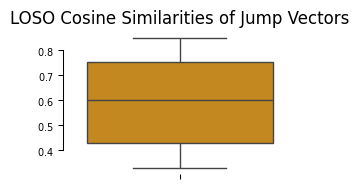

In [22]:
# correlation of the direction of force changes in jump between participants
jump_vector = post_clamp_forces - clamp_end_forces

# calculate leave one out cosine similarity of jump_vector across participants
similarities = []
for i in range(len(jump_vector)):
    left_out_vector = jump_vector[i]
    other_vectors = np.delete(jump_vector, i, axis=0)
    mean_other_vector = np.mean(other_vectors, axis=0)
    cosine_sim = np.dot(left_out_vector, mean_other_vector) / (np.linalg.norm(left_out_vector) * np.linalg.norm(mean_other_vector))
    similarities.append(cosine_sim)

plt.title('LOSO Cosine Similarities of Jump Vectors')
sns.boxplot(data=similarities, color = sns.color_palette('colorblind')[1])
sns.despine(trim=True)


print("LOSO Cosine Similarities:", np.mean(similarities))
stats.ttest_1samp(similarities, 0)

Cosine Similarities to Jump: -0.2266490780595441
TtestResult(statistic=-2.618361015264995, pvalue=0.025669820280242967, df=10)


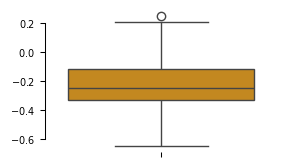

In [28]:

# within participant
# cos sim of the direcdtion of force change in induction to the direction of jump in test block

# to make it unbiased, use block 5-6 to 11 for induction, and block 12 to 13-14 for test

induction_last_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin([12])].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

jump_first_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin([11])].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

last_to_first_vector = induction_last_forces - clamp_start_forces
jump_vector = post_clamp_forces - jump_first_forces

similarities = []
for i in range(len(last_to_first_vector)):
    induction_vector = last_to_first_vector[i]
    jump_vector_i = jump_vector[i]
    cosine_sim = np.dot(induction_vector, jump_vector_i) / (np.linalg.norm(induction_vector) * np.linalg.norm(jump_vector_i))
    similarities.append(cosine_sim)

# sns.histplot(similarities, color = group_palette['Clamped'])
sns.boxplot(data=similarities, color = sns.color_palette('colorblind')[1])
print("Cosine Similarities to Jump:", np.mean(similarities))
print(stats.ttest_1samp(similarities, 0))
# plt.xlim(-0.9, 0.5)
# plt.title('Cosine Similarity of Clamp dynamics to Jump')
sns.despine(trim=True)

TtestResult(statistic=0.5387873544975833, pvalue=0.6018208074557574, df=10)
TtestResult(statistic=2.9479899648098336, pvalue=0.01458473438201744, df=10)


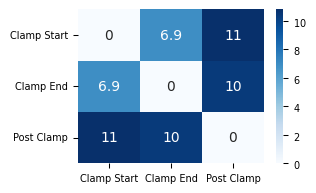

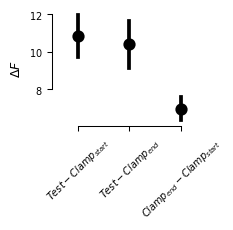

In [29]:
# plot 3 * 3 matrix of distances
force_distance_matrix = np.zeros((3, 3))
for i, forces_i in enumerate([clamp_start_forces, clamp_end_forces, post_clamp_forces]):
    for j, forces_j in enumerate([clamp_start_forces, clamp_end_forces, post_clamp_forces]):
        distances = np.linalg.norm(forces_i - forces_j, axis=1)
        force_distance_matrix[i, j] = np.mean(distances)
plt.figure(figsize=(3,2))
sns.heatmap(force_distance_matrix, annot=True, xticklabels=['Clamp Start', 'Clamp End', 'Post Clamp'], yticklabels=['Clamp Start', 'Clamp End', 'Post Clamp'], cmap = 'Blues')

# plot distance of test to first two and last two blocks
test_to_first_distances = np.linalg.norm(post_clamp_forces - clamp_start_forces, axis=1)
test_to_last_distances = np.linalg.norm(post_clamp_forces - clamp_end_forces, axis=1)
last_to_first_distances = np.linalg.norm(clamp_end_forces - clamp_start_forces, axis=1)  
plt.figure(figsize=(2, 1.5))
sns.pointplot(data=[test_to_first_distances, test_to_last_distances, last_to_first_distances], errorbar = 'se', linestyle ='', color = 'black')
# plt.xticks([0, 1], ['Test to First 2 Blocks', 'Test to Last 2 Blocks'])
plt.xticks([0, 1, 2], [r'$Test - Clamp_{start}$', r'$Test - Clamp_{end}$', r'$Clamp_{end} - Clamp_{start}$'], rotation=45)
plt.ylabel(r'$\Delta F$')
sns.despine(trim=True)

print(stats.ttest_rel(test_to_first_distances, test_to_last_distances))
print(stats.ttest_rel(test_to_last_distances, last_to_first_distances))

## Comparing Clamped and Unclamped

In [30]:
forces_wide_correct = utils.remove_error_trials(forces)
day1_forces = forces_wide_correct[forces_wide_correct['day'] == 1]
clamp_start_blocks = [4, 5, 6]
clamp_end_blocks = [10, 11, 12]
post_clamp_blocks = [13, 14]


# clamped group 
clamped_day1_forces = day1_forces[day1_forces['group'] == 'Clamped']

clamp_start_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(clamp_start_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

clamp_end_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(clamp_end_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

# Test
post_clamp_forces = np.array(clamped_day1_forces[clamped_day1_forces['BN'].isin(post_clamp_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())


# unclamped group
unclamped_day1_forces = day1_forces[day1_forces['group'] == 'Unclamped']

unclamped_start_forces = np.array(unclamped_day1_forces[unclamped_day1_forces['BN'].isin(clamp_start_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

unclamped_end_forces = np.array(unclamped_day1_forces[unclamped_day1_forces['BN'].isin(clamp_end_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

# Test
post_unclamped_forces = np.array(unclamped_day1_forces[unclamped_day1_forces['BN'].isin(post_clamp_blocks)].groupby(['SubNum']).agg({
    'force_vector': lambda x: np.mean(np.vstack(x), axis=0)
})['force_vector'].to_list())

In [31]:
# calculate within and between group distances during indtuciton and test

# leave one out distances of a subject's forces within and between group at each condition
# would be a 6 (3 condition, two groups) by 6 (3 condition, two groups) matrix of distances
distances = []
groups = ['Clamped', 'Unclamped']
conditions = ['Start', 'End', 'Test']
for i, group_i in enumerate(groups):
    for j, group_j in enumerate(groups):
        for k, condition_i in enumerate(conditions):
            for l, condition_j in enumerate(conditions):
                if group_i == 'Clamped':
                    forces_i = [clamp_start_forces, clamp_end_forces, post_clamp_forces][k]
                else:
                    forces_i = [unclamped_start_forces, unclamped_end_forces, post_unclamped_forces][k]

                if group_j == 'Clamped':
                    forces_j = [clamp_start_forces, clamp_end_forces, post_clamp_forces][l]
                else:
                    forces_j = [unclamped_start_forces, unclamped_end_forces, post_unclamped_forces][l]

                if group_i == group_j and condition_i == condition_j:
                    # within group and within condition: leave one out
                    for m in range(len(forces_i)):
                        left_out_vector = forces_i[m]
                        other_vectors = np.delete(forces_i, m, axis=0)
                        mean_other_vector = np.mean(other_vectors, axis=0)
                        distance = np.linalg.norm(left_out_vector - mean_other_vector)
                        distances.append({
                            'group_comparison': f'{group_i} {condition_i} to {group_j} {condition_j}',
                            'distance': distance
                        })
                else:
                    # between group or between condition: compare each vector to the mean of the other group/condition
                    mean_other_vector = np.mean(forces_j, axis=0)
                    for m in range(len(forces_i)):
                        left_out_vector = forces_i[m]
                        distance = np.linalg.norm(left_out_vector - mean_other_vector)
                        distances.append({
                            'group_comparison': f'{group_i} {condition_i} to {group_j} {condition_j}',
                            'distance': distance
                        })
distances_df = pd.DataFrame(distances)


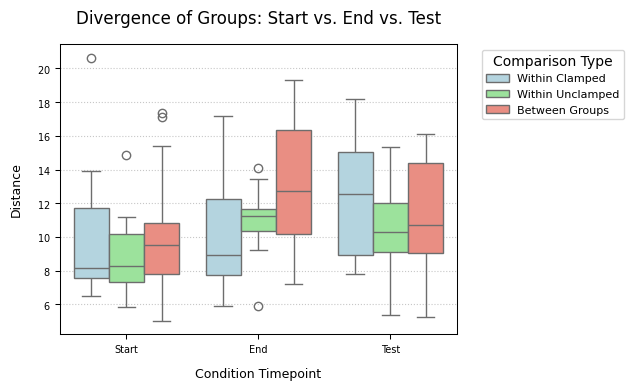

Statistical Comparisons:
Condition: Start
  Between Groups vs. Within Clamped: t=-0.27, p=0.7896
  Between Groups vs. Within Unclamped: t=0.78, p=0.4434
  Within Clamped vs. Within Unclamped: t=0.87, p=0.3972
Condition: End
  Between Groups vs. Within Clamped: t=2.36, p=0.0248
  Between Groups vs. Within Unclamped: t=1.88, p=0.0694
  Within Clamped vs. Within Unclamped: t=-0.70, p=0.4918
Condition: Test
  Between Groups vs. Within Clamped: t=-0.65, p=0.5182
  Between Groups vs. Within Unclamped: t=0.92, p=0.3640
  Within Clamped vs. Within Unclamped: t=1.34, p=0.1945


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Prepare the Data
# ---------------------------------------------------------
# Split the 'group_comparison' string into 'Source' and 'Target'
distances_df[['Source', 'Target']] = distances_df['group_comparison'].str.split(' to ', expand=True)

# Extract the underlying Group and Condition from the Source/Target columns
distances_df[['Source_Group', 'Source_Condition']] = distances_df['Source'].str.split(' ', n=1, expand=True)
distances_df[['Target_Group', 'Target_Condition']] = distances_df['Target'].str.split(' ', n=1, expand=True)

# Filter for comparisons that happen within the SAME timepoint (Start vs Start, End vs End, Test vs Test)
subset_df = distances_df[
    (distances_df['Source_Condition'] == distances_df['Target_Condition']) & 
    (distances_df['Source_Condition'].isin(['Start', 'End', 'Test'])) # Added 'Test'
].copy()

# ---------------------------------------------------------
# 2. Categorize them into Within vs. Between
# ---------------------------------------------------------
def determine_comparison_type(row):
    if row['Source_Group'] == row['Target_Group']:
        return f"Within {row['Source_Group']}"
    else:
        return "Between Groups"

subset_df['Comparison Type'] = subset_df.apply(determine_comparison_type, axis=1)

# ---------------------------------------------------------
# 3. Plot the divergence across all three timepoints
# ---------------------------------------------------------
utils.set_figure_style(scale="2col")


sns.boxplot(
    data=subset_df, 
    x='Source_Condition', 
    y='distance', 
    hue='Comparison Type',
    order=['Start', 'End', 'Test'], # Forces the correct chronological order on the X-axis
    hue_order=['Within Clamped', 'Within Unclamped', 'Between Groups'],
    palette=['lightblue', 'lightgreen', 'salmon']
)

plt.title('Divergence of Groups: Start vs. End vs. Test', pad=15)
plt.xlabel('Condition Timepoint', labelpad=10)
plt.ylabel('Distance', labelpad=10)
plt.legend(title='Comparison Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


### two by two comparisons of all conditions
print("Statistical Comparisons:")
# Get unique conditions for pairwise comparisons
unique_conditions = subset_df['group_comparison'].unique()
comparison_results = []
for i in range(len(unique_conditions)):
    for j in range(i + 1, len(unique_conditions)):
        cond_i = unique_conditions[i]
        cond_j = unique_conditions[j]

        if('Start' in cond_i) or ('Start' in cond_j):
            continue # skip comparisons involving 'Start' to focus on End vs Test
        
        data_i = subset_df[subset_df['group_comparison'] == cond_i]['distance']
        data_j = subset_df[subset_df['group_comparison'] == cond_j]['distance']
        
        # Perform t-test
        t_stat, p_value = stats.ttest_ind(data_i, data_j)
        
        comparison_results.append({
            'Comparison': f"{cond_i} vs. {cond_j}",
            't-statistic': t_stat,
            'p-value': p_value
        })
comparison_results_df = pd.DataFrame(comparison_results)

# for each source condition, compare the between group distance to the within group distance at the same timepoint
for condition in ['Start', 'End', 'Test']:
    within_clamped = subset_df[
        (subset_df['Comparison Type'] == 'Within Clamped') & 
        (subset_df['Source_Condition'] == condition)
    ]['distance']
    
    within_unclamped = subset_df[
        (subset_df['Comparison Type'] == 'Within Unclamped') & 
        (subset_df['Source_Condition'] == condition)
    ]['distance']
    
    between_groups = subset_df[
        (subset_df['Comparison Type'] == 'Between Groups') & 
        (subset_df['Source_Condition'] == condition)
    ]['distance']
    
    # Compare Between Groups to Within Clamped
    t_stat_clamped, p_value_clamped = stats.ttest_ind(between_groups, within_clamped)
    
    # Compare Between Groups to Within Unclamped
    t_stat_unclamped, p_value_unclamped = stats.ttest_ind(between_groups, within_unclamped)
    
    print(f"Condition: {condition}")
    print(f"  Between Groups vs. Within Clamped: t={t_stat_clamped:.2f}, p={p_value_clamped:.4f}")
    print(f"  Between Groups vs. Within Unclamped: t={t_stat_unclamped:.2f}, p={p_value_unclamped:.4f}")
    print(f"  Within Clamped vs. Within Unclamped: t={stats.ttest_ind(within_clamped, within_unclamped)[0]:.2f}, p={stats.ttest_ind(within_clamped, within_unclamped)[1]:.4f}")

In [35]:
#Template is the normalized average change vector across subjects

# calculate template change vector for clamped
change_clamped = clamp_end_forces - clamp_start_forces
# normalize average change vector to get template
template_clamped = np.mean(change_clamped, axis=0)
template_clamped_norm = template_clamped / np.linalg.norm(template_clamped)


# calculate template jump vector for clamped
jump_clamped = post_clamp_forces - clamp_end_forces
# normalize average jump vector to get template
template_jump_clamped = np.mean(jump_clamped, axis=0)
template_jump_clamped_norm = template_jump_clamped / np.linalg.norm(template_jump_clamped)


# use templates to fit change in unclamped for each subject
change_unclamped = post_unclamped_forces - unclamped_start_forces
change_unclamped_norm = change_unclamped / np.linalg.norm(change_unclamped, axis=1, keepdims=True)

In [36]:
# cos sim of template_jump_clamped and template_clamped
template_sim = np.dot(template_jump_clamped, template_clamped) / (np.linalg.norm(template_jump_clamped) * np.linalg.norm(template_clamped))
print("Cosine Similarity of Clamped Template and Jump Template:", template_sim)

Cosine Similarity of Clamped Template and Jump Template: -0.07097890913020702



--- Hyperplane Fit Coefficients ---
Subject 0: Clamp Weight = -0.058, Jump Weight = 0.057
Subject 1: Clamp Weight = -0.084, Jump Weight = 0.053
Subject 2: Clamp Weight = -0.048, Jump Weight = 0.082
Subject 3: Clamp Weight = 0.013, Jump Weight = 0.120
Subject 4: Clamp Weight = -0.124, Jump Weight = 0.008
Subject 5: Clamp Weight = -0.137, Jump Weight = 0.041
Subject 6: Clamp Weight = -0.022, Jump Weight = 0.115
Subject 7: Clamp Weight = 0.092, Jump Weight = 0.079
Subject 8: Clamp Weight = -0.157, Jump Weight = -0.031
Subject 9: Clamp Weight = 0.137, Jump Weight = 0.095
Subject 10: Clamp Weight = 0.097, Jump Weight = 0.039
ttest of clamp weights: TtestResult(statistic=-0.8772437914731349, pvalue=0.40093822194898665, df=10)
ttest of jump weights: TtestResult(statistic=4.377996596261136, pvalue=0.0013817179255428854, df=10)


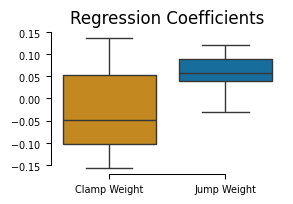

In [41]:
utils.set_figure_style(scale = "1col")
# Create a design matrix (basis_matrix) where the templates are column vectors.
# Assuming templates have shape (D,), basis_matrix will have shape (D, 2)
basis_matrix = np.column_stack((template_clamped, template_jump_clamped))

# Solve the least squares problem: basis_matrix * coefficients = change_unclamped
# We transpose change_unclamped to shape (D, N) to match the equation Ax = B
# 'rcond=None' is used to silence a common numpy deprecation warning
coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    basis_matrix, 
    change_unclamped_norm.T, 
    # change_unclamped.T,
    rcond=None
)

# Transpose coefficients back to shape (N, 2) so each row corresponds to a subject
coefficients = coefficients.T 

# (Optional) Reconstruct the fitted vectors lying exactly on the hyperplane
fitted_changes_unclamped = coefficients @ basis_matrix.T

# Print the final weights for each subject in the basis of the hyperplane
print("\n--- Hyperplane Fit Coefficients ---")
for subnum, (weight_clamp, weight_jump) in enumerate(coefficients):
    print(f'Subject {subnum}: Clamp Weight = {weight_clamp:.3f}, Jump Weight = {weight_jump:.3f}')

# box plot of the coefficients
coefficients_df = pd.DataFrame(coefficients, columns=['Clamp Weight', 'Jump Weight'])
sns.boxplot(data=coefficients_df, palette=[group_palette['Clamped'], group_palette['Unclamped']])
plt.title('Regression Coefficients')
sns.despine(trim=True)
# plt.savefig(path_figs + 'unclamped_change_regression_coefficients.pdf', bbox_inches='tight')

print("ttest of clamp weights:", stats.ttest_1samp(coefficients[:, 0], 0))
print("ttest of jump weights:", stats.ttest_1samp(coefficients[:, 1], 0))

--- Subject 0 ---
CV VAF Full Model:  24.78%
CV VAF Clamp Only:  5.97%
CV VAF Jump Only:   19.96%

--- Subject 1 ---
CV VAF Full Model:  25.68%
CV VAF Clamp Only:  9.43%
CV VAF Jump Only:   18.16%

--- Subject 2 ---
CV VAF Full Model:  35.99%
CV VAF Clamp Only:  1.86%
CV VAF Jump Only:   35.63%

--- Subject 3 ---
CV VAF Full Model:  72.02%
CV VAF Clamp Only:  -0.43%
CV VAF Jump Only:   72.02%

--- Subject 4 ---
CV VAF Full Model:  17.03%
CV VAF Clamp Only:  18.54%
CV VAF Jump Only:   -1.94%

--- Subject 5 ---
CV VAF Full Model:  37.14%
CV VAF Clamp Only:  28.43%
CV VAF Jump Only:   11.35%

--- Subject 6 ---
CV VAF Full Model:  71.61%
CV VAF Clamp Only:  1.59%
CV VAF Jump Only:   70.87%

--- Subject 7 ---
CV VAF Full Model:  38.75%
CV VAF Clamp Only:  9.62%
CV VAF Jump Only:   27.02%

--- Subject 8 ---
CV VAF Full Model:  32.42%
CV VAF Clamp Only:  26.56%
CV VAF Jump Only:   3.88%

--- Subject 9 ---
CV VAF Full Model:  60.36%
CV VAF Clamp Only:  15.32%
CV VAF Jump Only:   35.99%

--- Su

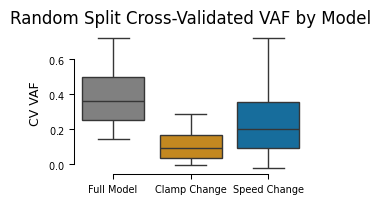

In [43]:

utils.set_figure_style(scale = "1col")


# Initialize arrays to store the CROSS-VALIDATED VAFs
cv_vaf_full = []
cv_vaf_clamp_only = []
cv_vaf_jump_only = []

for subnum, y in enumerate(change_unclamped_norm):
    # ==========================================
    # DATA SPLITTING (Random 50/50 Split)
    # ==========================================
    n_points = len(y)
    
    # Generate a randomly shuffled array of all indices
    shuffled_indices = np.random.permutation(n_points)
    
    # Find the midpoint to split 50/50
    split_point = n_points // 2
    
    # Assign the first half to train, second half to test
    train_idx = shuffled_indices[:split_point]
    test_idx = shuffled_indices[split_point:]
    
    # Slice the data and templates based on the random indices
    y_train, y_test = y[train_idx], y[test_idx]
    
    temp_clamp_train = template_clamped[train_idx]
    temp_clamp_test  = template_clamped[test_idx]
    
    temp_jump_train = template_jump_clamped[train_idx]
    temp_jump_test  = template_jump_clamped[test_idx]
    
    # Rebuild the basis matrix specifically for the training indices
    basis_matrix_train = np.column_stack((temp_clamp_train, temp_jump_train))
    
    # Total Variance of the TEST set (Uncentered SST)
    sst_test = np.sum(y_test**2) 
    
    # ==========================================
    # 1. Full Model (Both Templates)
    # ==========================================
    # FIT on Training Data
    coef, _, _, _ = np.linalg.lstsq(basis_matrix_train, y_train, rcond=None)
    
    # PREDICT on Testing Data
    y_hat_full_test = coef[0] * temp_clamp_test + coef[1] * temp_jump_test
    
    # EVALUATE on Testing Data
    error_full_test = np.sum((y_test - y_hat_full_test)**2)
    cv_vaf_full.append(1 - (error_full_test / sst_test))
    
    # ==========================================
    # 2. Reduced Model A (Clamp Template Only)
    # ==========================================
    # FIT on Training Data
    weight_clamp = np.dot(y_train, temp_clamp_train) / np.dot(temp_clamp_train, temp_clamp_train)
    
    # PREDICT on Testing Data
    y_hat_clamp_test = weight_clamp * temp_clamp_test
    
    # EVALUATE on Testing Data
    error_clamp_test = np.sum((y_test - y_hat_clamp_test)**2)
    cv_vaf_clamp_only.append(1 - (error_clamp_test / sst_test))

    # ==========================================
    # 3. Reduced Model B (Jump Template Only)
    # ==========================================
    # FIT on Training Data
    weight_jump = np.dot(y_train, temp_jump_train) / np.dot(temp_jump_train, temp_jump_train)
    
    # PREDICT on Testing Data
    y_hat_jump_test = weight_jump * temp_jump_test
    
    # EVALUATE on Testing Data
    error_jump_test = np.sum((y_test - y_hat_jump_test)**2)
    cv_vaf_jump_only.append(1 - (error_jump_test / sst_test))

    # Print results for the current subject
    print(f"--- Subject {subnum} ---")
    print(f"CV VAF Full Model:  {cv_vaf_full[-1] * 100:.2f}%")
    print(f"CV VAF Clamp Only:  {cv_vaf_clamp_only[-1] * 100:.2f}%")
    print(f"CV VAF Jump Only:   {cv_vaf_jump_only[-1] * 100:.2f}%\n")

# Print the overall summary across all subjects
print("==================================================")
print("AVERAGE CROSS-VALIDATED VARIANCE ACCOUNTED FOR (VAF)")
print("==================================================")
print(f"Full Model:      {np.mean(cv_vaf_full) * 100:.2f}%")
print(f"Clamp Only:      {np.mean(cv_vaf_clamp_only) * 100:.2f}%")
print(f"Jump Only:       {np.mean(cv_vaf_jump_only) * 100:.2f}%")

# Box plot of the CV VAF for each model
vaf_df = pd.DataFrame({
    'Full Model': cv_vaf_full,
    'Clamp Change': cv_vaf_clamp_only,
    'Speed Change': cv_vaf_jump_only
})

sns.boxplot(data=vaf_df, palette=['gray', group_palette['Clamped'], group_palette['Unclamped']])
plt.title('Random Split Cross-Validated VAF by Model')
plt.ylabel('CV VAF')
sns.despine(trim=True)
# plt.savefig(path_figs + 'unclamped_change_explained_variance_random_split.pdf', bbox_inches='tight')

# T-test to compare CV VAF of full model to reduced models
print("\nT-test CV Full Model vs Clamp Only:", stats.ttest_rel(cv_vaf_full, cv_vaf_clamp_only))
print("T-test CV Full Model vs Jump Only:", stats.ttest_rel(cv_vaf_full, cv_vaf_jump_only))

# T-Test for reduced models against zero
print("\nT-test Clamp Only vs 0:", stats.ttest_1samp(cv_vaf_clamp_only, 0))
print("T-test Jump Only vs 0:", stats.ttest_1samp(cv_vaf_jump_only, 0))

--- Subject 0 ---
CV VAF Full Model:  17.46%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   17.46%

--- Subject 1 ---
CV VAF Full Model:  8.65%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   8.65%

--- Subject 2 ---
CV VAF Full Model:  36.49%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   36.49%

--- Subject 3 ---
CV VAF Full Model:  74.61%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   74.71%

--- Subject 4 ---
CV VAF Full Model:  0.81%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   0.81%

--- Subject 5 ---
CV VAF Full Model:  11.11%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   11.11%

--- Subject 6 ---
CV VAF Full Model:  71.06%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   71.06%

--- Subject 7 ---
CV VAF Full Model:  43.44%
CV VAF Clamp Only:  7.29%
CV VAF Jump Only:   34.72%

--- Subject 8 ---
CV VAF Full Model:  0.00%
CV VAF Clamp Only:  0.00%
CV VAF Jump Only:   0.00%

--- Subject 9 ---
CV VAF Full Model:  65.38%
CV VAF Clamp Only:  19.32%
CV VAF Jump Only:   46.25%

--- Subject 10 

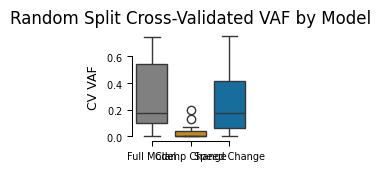

In [45]:
import scipy.optimize as opt

utils.set_figure_style(scale = "1col")
# halve the width of the figure
width, height = plt.gcf().get_size_inches()
plt.gcf().set_size_inches(width / 2, height/1.3)

# Initialize arrays to store the CROSS-VALIDATED VAFs
cv_vaf_full = []
cv_vaf_clamp_only = []
cv_vaf_jump_only = []

for subnum, y in enumerate(change_unclamped_norm):
    n_points = len(y)
    shuffled_indices = np.random.permutation(n_points)
    split_point = n_points // 2

    train_idx = shuffled_indices[:split_point]
    test_idx = shuffled_indices[split_point:]

    y_train, y_test = y[train_idx], y[test_idx]

    temp_clamp_train = template_clamped[train_idx]
    temp_clamp_test  = template_clamped[test_idx]

    temp_jump_train = template_jump_clamped[train_idx]
    temp_jump_test  = template_jump_clamped[test_idx]

    basis_matrix_train = np.column_stack((temp_clamp_train, temp_jump_train))
    sst_test = np.sum(y_test**2)

    # 1. Full Model (non-negative coefficients)
    coef, _ = opt.nnls(basis_matrix_train, y_train)
    y_hat_full_test = coef[0] * temp_clamp_test + coef[1] * temp_jump_test
    error_full_test = np.sum((y_test - y_hat_full_test)**2)
    cv_vaf_full.append(1 - (error_full_test / sst_test))

    # 2. Clamp Only (non-negative)
    weight_clamp = max(0, np.dot(y_train, temp_clamp_train) / np.dot(temp_clamp_train, temp_clamp_train))
    y_hat_clamp_test = weight_clamp * temp_clamp_test
    error_clamp_test = np.sum((y_test - y_hat_clamp_test)**2)
    cv_vaf_clamp_only.append(1 - (error_clamp_test / sst_test))

    # 3. Jump Only (non-negative)
    weight_jump = max(0, np.dot(y_train, temp_jump_train) / np.dot(temp_jump_train, temp_jump_train))
    y_hat_jump_test = weight_jump * temp_jump_test
    error_jump_test = np.sum((y_test - y_hat_jump_test)**2)
    cv_vaf_jump_only.append(1 - (error_jump_test / sst_test))

    print(f"--- Subject {subnum} ---")
    print(f"CV VAF Full Model:  {cv_vaf_full[-1] * 100:.2f}%")
    print(f"CV VAF Clamp Only:  {cv_vaf_clamp_only[-1] * 100:.2f}%")
    print(f"CV VAF Jump Only:   {cv_vaf_jump_only[-1] * 100:.2f}%\n")

# Print the overall summary across all subjects
print("==================================================")
print("AVERAGE CROSS-VALIDATED VARIANCE ACCOUNTED FOR (VAF)")
print("==================================================")
print(f"Full Model:      {np.mean(cv_vaf_full) * 100:.2f}%")
print(f"Clamp Only:      {np.mean(cv_vaf_clamp_only) * 100:.2f}%")
print(f"Jump Only:       {np.mean(cv_vaf_jump_only) * 100:.2f}%")

# Box plot of the CV VAF for each model
vaf_df = pd.DataFrame({
    'Full Model': cv_vaf_full,
    'Clamp Change': cv_vaf_clamp_only,
    'Speed Change': cv_vaf_jump_only
})

sns.boxplot(data=vaf_df, palette=['gray', group_palette['Clamped'], group_palette['Unclamped']])
plt.title('Random Split Cross-Validated VAF by Model')
plt.ylabel('CV VAF')
sns.despine(trim=True)

# T-test to compare CV VAF of full model to reduced models
print("\nT-test CV Full Model vs Clamp Only:", stats.ttest_rel(cv_vaf_full, cv_vaf_clamp_only))
print("T-test CV Full Model vs Jump Only:", stats.ttest_rel(cv_vaf_full, cv_vaf_jump_only))

# T-Test models against zero
print("\nT-test Clamp Only vs 0:", stats.ttest_1samp(cv_vaf_clamp_only, 0))
print("T-test Jump Only vs 0:", stats.ttest_1samp(cv_vaf_jump_only, 0))
print("\nT-test Full Model vs 0:", stats.ttest_1samp(cv_vaf_full, 0))
